# Notebook 03 — Generalisation Experiments (Part A)

All models are **trained** under the default setting ($s=50$, noiseless).
We then test them under distribution shifts:

| Experiment | Change |
|------------|--------|
| A | Sparsity increased: $s = 75$ |
| B | Different non-zero magnitude: $\sigma_{\text{mag}} = 3$ |
| C | Noisy observations: $\sigma = 0.01$ (SNR ≈ 30 dB) |

This replicates Fig. 5 of the HyperLISTA paper.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import torch
import matplotlib.pyplot as plt
import pandas as pd

from src.data.sparse_generator import build_sparse_dataloaders
from src.models.ista       import ISTA
from src.models.fista      import FISTA
from src.models.lista      import LISTA
from src.models.alista     import ALISTA
from src.models.hyperlista import HyperLISTA
from src.training.trainer  import train
from src.training.tuner    import tune_hyperlista
from src.evaluation.visualizer import plot_nmse_vs_layers, get_layerwise_nmse

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_LAYERS = 16
M, N, S  = 250, 500, 50
print('Device:', DEVICE)

Device: cuda


## 1. Train all models on the default distribution

In [2]:
A, train_loader, val_loader, _ = build_sparse_dataloaders(
    m=M, n=N, s=S, sigma=0.0,
    n_train=51200, n_val=2048, n_test=2048,
    batch_size=256, device=DEVICE, seed=42,
)

# --- LISTA ---
lista = LISTA(A, n_layers=N_LAYERS).to(DEVICE)
train(lista, train_loader, val_loader, n_epochs=50, lr=1e-3, device=DEVICE, patience=15)

# --- ALISTA ---
alista = ALISTA(A, n_layers=N_LAYERS, W_iters=2000).to(DEVICE)
train(alista, train_loader, val_loader, n_epochs=50, lr=5e-4, device=DEVICE, patience=15)

# --- HyperLISTA ---
hyperlista = HyperLISTA(A, n_layers=N_LAYERS, W_iters=2000).to(DEVICE)
tune_hyperlista(hyperlista, val_loader, DEVICE, verbose=False)

# --- Classical baselines ---
ista  = ISTA(A, lam=0.1, n_iter=N_LAYERS).to(DEVICE)
fista = FISTA(A, lam=0.1, n_iter=N_LAYERS).to(DEVICE)

models = {
    'ISTA': ista, 'FISTA': fista,
    'LISTA': lista, 'ALISTA': alista,
    'HyperLISTA': hyperlista,
}
print('Training done.')

Training: 100%|██████████| 50/50 [02:04<00:00,  2.50s/epoch, lr=5.00e-04, train_loss=0.0001, val_nmse=-29.98 dB]


Training done.


In [3]:
import json, os
os.makedirs('../results/checkpoints', exist_ok=True)
torch.save(lista.state_dict(),  '../results/checkpoints/lista_partA_genexp.pt')
torch.save(alista.state_dict(), '../results/checkpoints/alista_partA_genexp.pt')
with open('../results/checkpoints/hyperlista_partA_genexp_hparams.json', 'w') as f:
    json.dump({'c1': hyperlista.c1, 'c2': hyperlista.c2, 'c3': hyperlista.c3}, f)
print('Checkpoints saved.')

Checkpoints saved.


## 2. Define generalisation test function

In [4]:
def eval_on_shifted(A, models, s_test, sigma_test, mag_std_test, label):
    _, _, _, test_ood = build_sparse_dataloaders(
        m=M, n=N, s=s_test, sigma=sigma_test,
        magnitude_std=mag_std_test,
        n_train=512, n_val=512, n_test=2048,
        batch_size=256, device=DEVICE, seed=99,
    )
    print(f'\n=== {label} ===')
    results = {}
    for name, model in models.items():
        nmse_list = get_layerwise_nmse(model, test_ood, DEVICE)
        results[name] = nmse_list
        print(f'  {name:12s}: {nmse_list[-1]:.2f} dB')
    return results, test_ood

## 3. Experiment A: Increased sparsity (s=75)


=== Sparsity shift: s=75 ===
  ISTA        : 1.55 dB
  FISTA       : 2.13 dB
  LISTA       : 3.22 dB
  ALISTA      : 4.69 dB
  HyperLISTA  : 0.39 dB


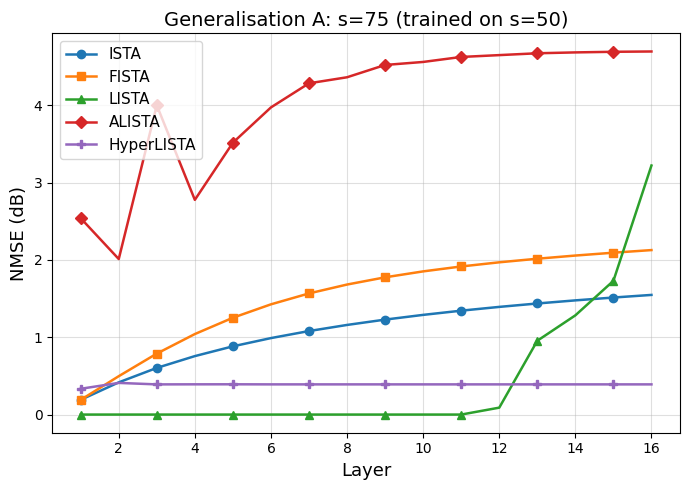

In [5]:
res_A, _ = eval_on_shifted(A, models, s_test=75, sigma_test=0.0, mag_std_test=1.0,
                            label='Sparsity shift: s=75')
fig = plot_nmse_vs_layers(res_A, title='Generalisation A: s=75 (trained on s=50)')
plt.show()

## 4. Experiment B: Larger non-zero magnitude (σ_mag=3)


=== Magnitude shift: σ_mag=3 ===
  ISTA        : 1.88 dB
  FISTA       : 2.56 dB
  LISTA       : 3.43 dB
  ALISTA      : 4.19 dB
  HyperLISTA  : 0.39 dB


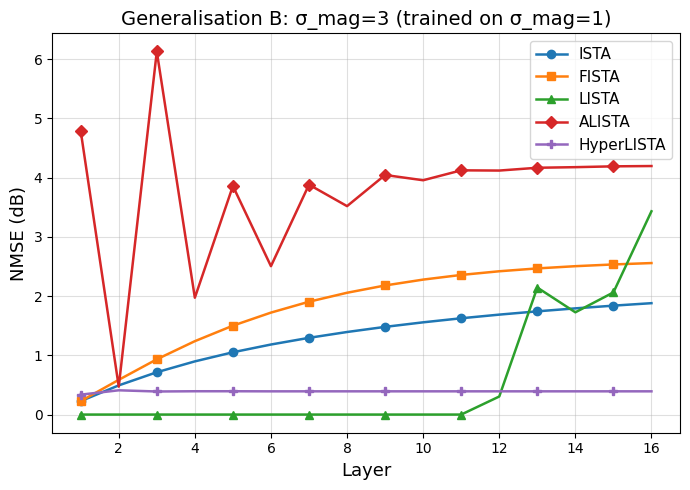

In [6]:
res_B, _ = eval_on_shifted(A, models, s_test=S, sigma_test=0.0, mag_std_test=3.0,
                            label='Magnitude shift: σ_mag=3')
fig = plot_nmse_vs_layers(res_B, title='Generalisation B: σ_mag=3 (trained on σ_mag=1)')
plt.show()

## 5. Experiment C: Additive noise (SNR ≈ 30 dB)


=== Noise shift: σ=0.01 ===
  ISTA        : 1.44 dB
  FISTA       : 2.00 dB
  LISTA       : 3.12 dB
  ALISTA      : 4.80 dB
  HyperLISTA  : 0.39 dB


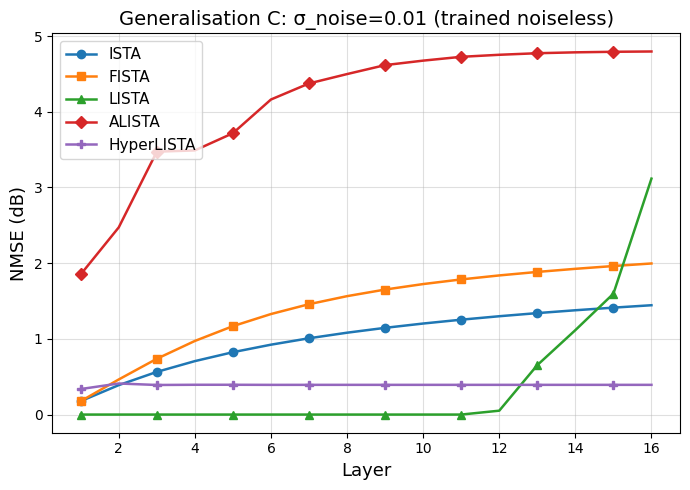

In [7]:
res_C, _ = eval_on_shifted(A, models, s_test=S, sigma_test=0.01, mag_std_test=1.0,
                            label='Noise shift: σ=0.01')
fig = plot_nmse_vs_layers(res_C, title='Generalisation C: σ_noise=0.01 (trained noiseless)')
plt.show()

## 6. Combined figure (2×2 subplots)


=== Original (sanity check) ===
  ISTA        : 1.44 dB
  FISTA       : 1.99 dB
  LISTA       : 3.11 dB
  ALISTA      : 4.79 dB
  HyperLISTA  : 0.39 dB


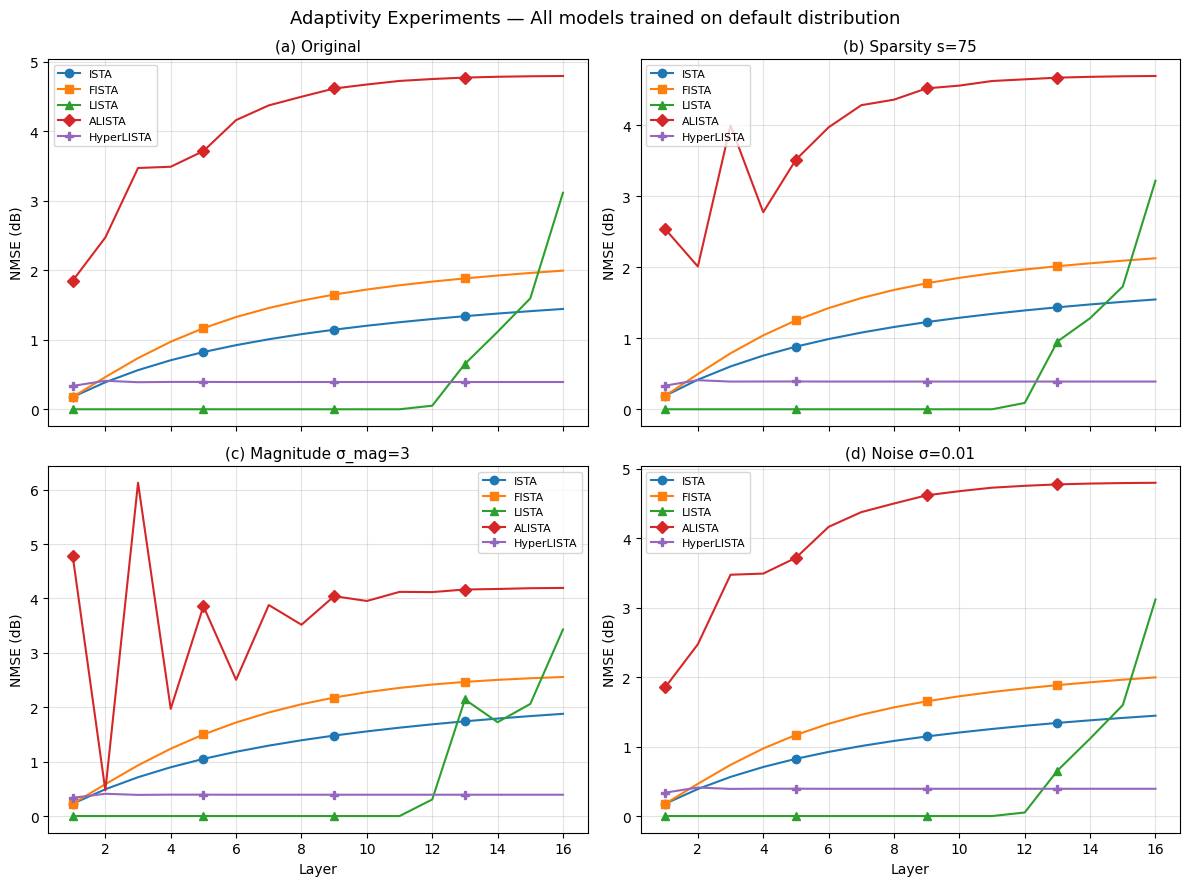

In [8]:
import matplotlib.pyplot as plt

_, base_loader = eval_on_shifted(A, models, s_test=S, sigma_test=0.0, mag_std_test=1.0,
                                  label='Original (sanity check)')
res_0 = {name: get_layerwise_nmse(m, base_loader, DEVICE) for name, m in models.items()}

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
subtitles = [
    ('(a) Original',          res_0),
    ('(b) Sparsity s=75',     res_A),
    ('(c) Magnitude σ_mag=3', res_B),
    ('(d) Noise σ=0.01',      res_C),
]
markers = ['o', 's', '^', 'D', 'P']
colors  = plt.cm.tab10.colors

for ax, (title, res) in zip(axes.flat, subtitles):
    for idx, (name, vals) in enumerate(res.items()):
        ax.plot(range(1, len(vals)+1), vals, label=name,
                marker=markers[idx], markevery=4,
                color=colors[idx], linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('NMSE (dB)')
    ax.grid(alpha=0.35)
    ax.legend(fontsize=8)

for ax in axes[1]:
    ax.set_xlabel('Layer')

fig.suptitle('Adaptivity Experiments — All models trained on default distribution',
             fontsize=13)
fig.tight_layout()
fig.savefig('adaptivity_experiments.pdf', bbox_inches='tight')
plt.show()